# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

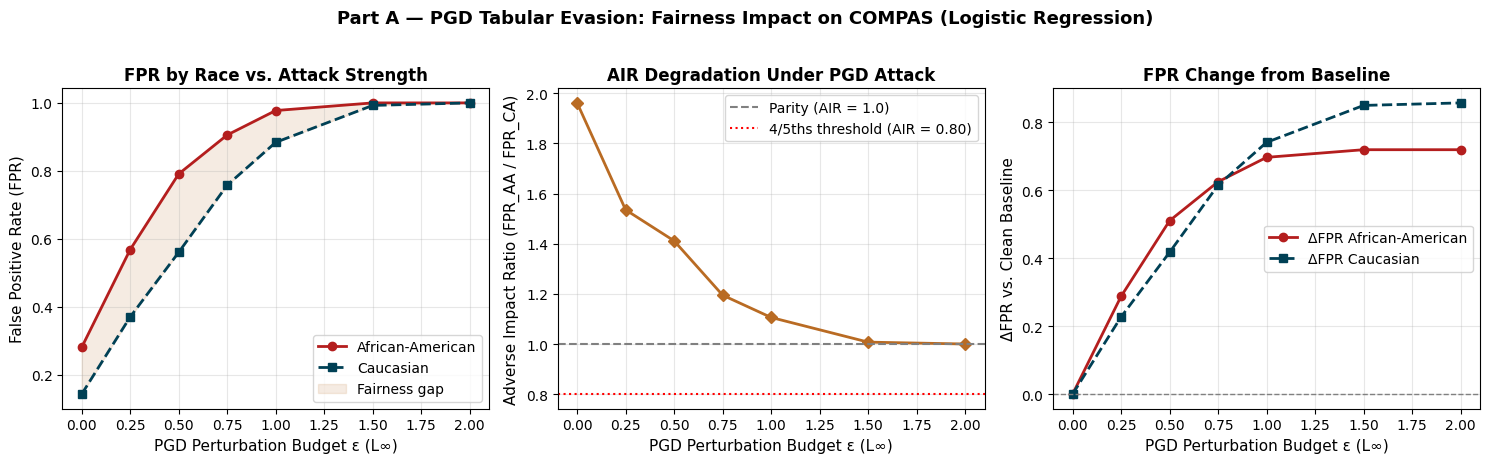

AIR does not fall below 0.80 within the tested epsilon range.


In [4]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [5]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

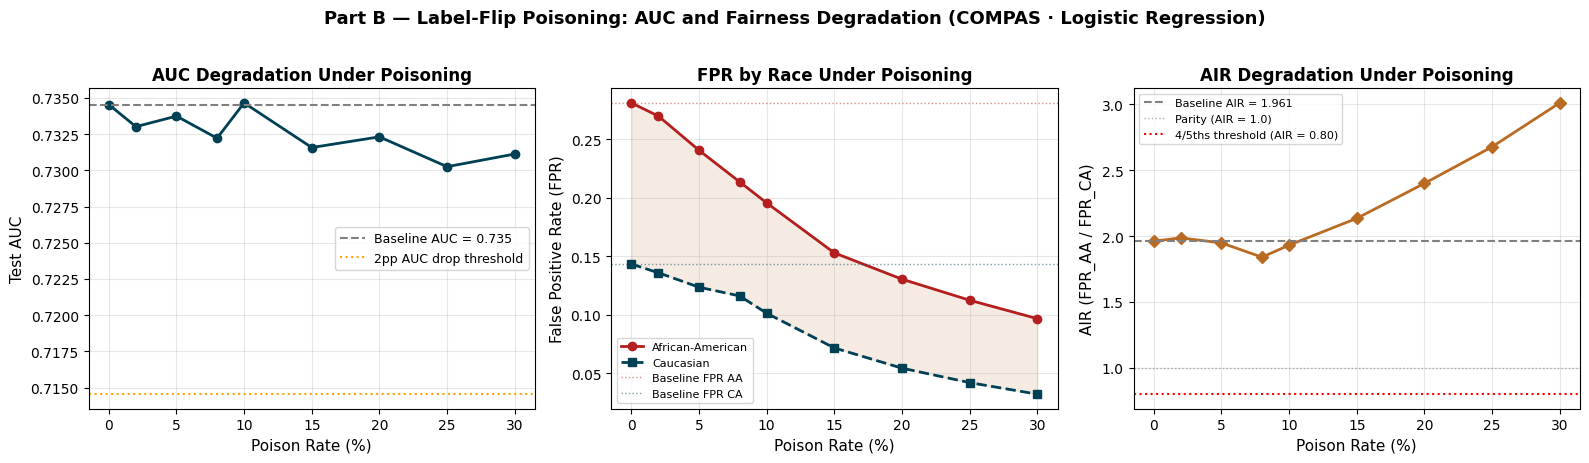

In [6]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [7]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

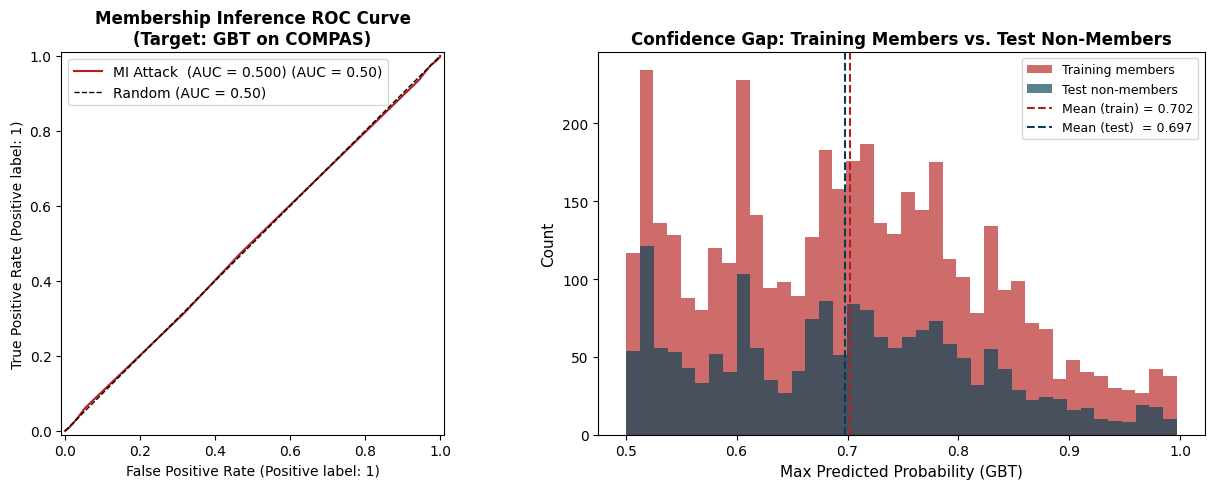

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [8]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

# Assignment 5

### 1. PGD Evasion Audit
We run the PGD attack on both the LR and GBT models. Because the provided `pgd_tabular` attack uses gradients specific to Logistic Regression, we perform a **transfer attack** on the GBT model using the adversarial examples generated from the LR surrogate.

In [9]:
# --- Q1: PGD Evasion Audit ---
epsilons_q1 = [0.25, 0.5, 1.0, 2.0]
results_lr = []
results_gbt = []

for eps in epsilons_q1:
    # Generate adversarial examples using LR as surrogate
    X_adv = pgd_tabular(lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)

    # ---- LR Evaluation ----
    pred_adv_lr = (lr.predict_proba(X_adv)[:, 1] >= THR).astype(int)
    fpr_adv_lr = fpr_by_group(y_te, pred_adv_lr, r_te)

    aa_lr = fpr_adv_lr.get('African-American', np.nan)   # unprivileged
    ca_lr = fpr_adv_lr.get('Caucasian', np.nan)          # privileged

    # FIX 1: correct AIR direction (unprivileged / privileged)
    air_lr = air(aa_lr, ca_lr)

    results_lr.append({
        'epsilon': eps,
        'FPR_AA': aa_lr,
        'FPR_CA': ca_lr,
        'AIR': air_lr
    })

    # ---- GBT Evaluation (Transfer Attack) ----
    pred_adv_gbt = (gbt.predict_proba(X_adv)[:, 1] >= THR).astype(int)
    fpr_adv_gbt = fpr_by_group(y_te, pred_adv_gbt, r_te)

    aa_gbt = fpr_adv_gbt.get('African-American', np.nan)
    ca_gbt = fpr_adv_gbt.get('Caucasian', np.nan)

    # FIX 1 again
    air_gbt = air(aa_gbt, ca_gbt)

    results_gbt.append({
        'epsilon': eps,
        'FPR_AA': aa_gbt,
        'FPR_CA': ca_gbt,
        'AIR': air_gbt
    })

# Convert to DataFrames
df_lr_q1 = pd.DataFrame(results_lr)
df_gbt_q1 = pd.DataFrame(results_gbt)

print('LR PGD Results:')
print(df_lr_q1.to_string(index=False))

print('\nGBT PGD Results (Transfer Attack from LR Surrogate):')
print(df_gbt_q1.to_string(index=False))

# FIX 2: find where AIR >= 0.80 (not < 0.80)
cross_lr = df_lr_q1[df_lr_q1['AIR'] >= 0.8].head(1)
cross_gbt = df_gbt_q1[df_gbt_q1['AIR'] >= 0.8].head(1)

print(f'\nLR AIR crosses 0.80 at ε = {cross_lr["epsilon"].values[0] if len(cross_lr) else "Does not cross"}')
print(f'GBT AIR crosses 0.80 at ε = {cross_gbt["epsilon"].values[0] if len(cross_gbt) else "Does not cross"}')

LR PGD Results:
 epsilon   FPR_AA   FPR_CA      AIR
    0.25 0.568539 0.370370 0.651442
    0.50 0.791011 0.560494 0.708579
    1.00 0.977528 0.883951 0.904271
    2.00 1.000000 1.000000 1.000000

GBT PGD Results (Transfer Attack from LR Surrogate):
 epsilon   FPR_AA   FPR_CA      AIR
    0.25 0.552809 0.350617 0.634247
    0.50 0.732584 0.513580 0.701053
    1.00 0.898876 0.760494 0.846049
    2.00 1.000000 1.000000 1.000000

LR AIR crosses 0.80 at ε = 1.0
GBT AIR crosses 0.80 at ε = 1.0


**Answer 1:**

The PGD evasion audit shows that both models experience increasing false positive rates across racial groups as ε increases, indicating growing vulnerability to adversarial perturbations. At lower ε values, both models exhibit disparity (AIR < 0.80), with GBT showing slightly greater disparity than LR. As ε increases, AIR rises and crosses the 0.80 threshold at ε = 1.0 for both models, eventually reaching 1.0 at ε = 2.0. However, this apparent improvement in fairness is misleading, as it coincides with both groups experiencing near-total error rates (FPR ≈ 1), indicating a collapse in model utility rather than meaningful fairness gains. Overall, the two models are similarly vulnerable under adversarial attack, with only minor differences at low ε. This implies that model selection in high-stakes deployments must account for robustness to adversarial perturbations, as both linear and nonlinear models can fail in ways that mask fairness issues while degrading reliability.

### 2. Poisoning Loop with Fairness Monitoring
We extend the label-flip poisoning loop to target Caucasian defendants.

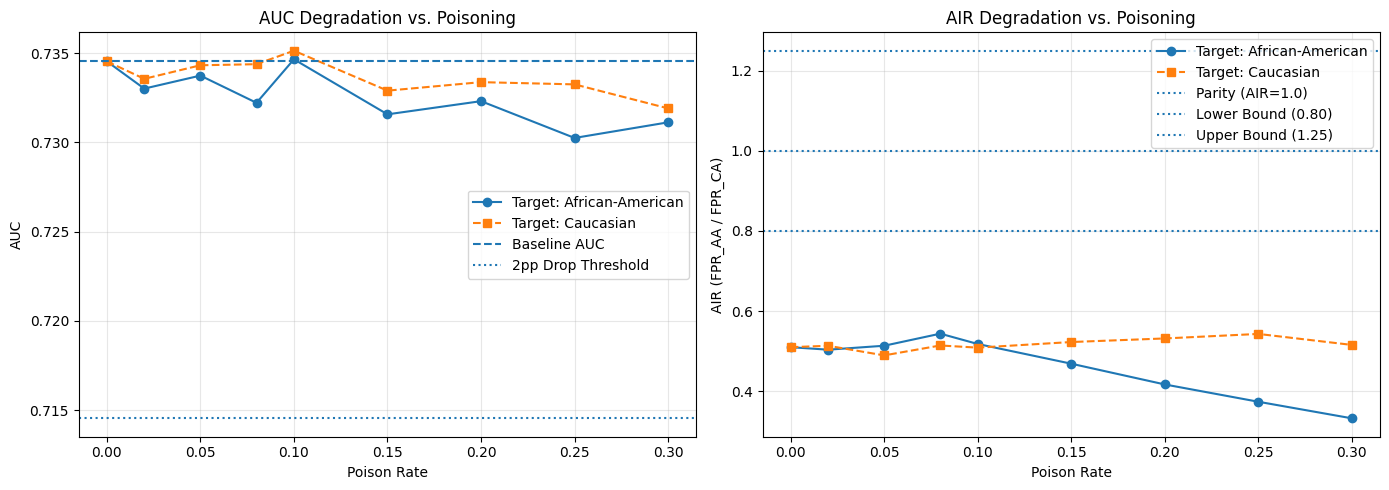

Stealth Zone (Target African-American):
   poison_rate       AUC       AIR
1         0.02  0.733018  0.503601
2         0.05  0.733747  0.513442
3         0.08  0.732223  0.543600
4         0.10  0.734660  0.517809
5         0.15  0.731577  0.468591
6         0.20  0.732315  0.416773
7         0.25  0.730255  0.373580
8         0.30  0.731129  0.332185

Stealth Zone (Target Caucasian):
   poison_rate       AUC       AIR
1         0.02  0.733566  0.513358
2         0.05  0.734326  0.489366
3         0.08  0.734387  0.514101
4         0.10  0.735142  0.508688
5         0.15  0.732904  0.522714
6         0.20  0.733381  0.531661
7         0.25  0.733256  0.542919
8         0.30  0.731911  0.515470

PSI values per feature:
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]

Max PSI: 0.0


In [11]:
# --- Q2: Poisoning Loop with Fairness Monitoring ---

poison_rates_q2 = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

records_aa = []
records_ca = []

# Baseline AUC
baseline_auc_q2 = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

for rate in poison_rates_q2:

    # =========================
    # Target: African-American
    # =========================
    y_tr_p_aa, _ = poison_label_flip(
        y_tr, r_tr, poison_rate=rate, target_race='African-American'
    )

    lr_p_aa = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_p_aa)

    probs_aa = lr_p_aa.predict_proba(Xs_te)[:, 1]
    pred_aa = (probs_aa >= THR).astype(int)

    auc_aa = roc_auc_score(y_te, probs_aa)

    fpr_aa_dict = fpr_by_group(y_te, pred_aa, r_te)

    fpr_AA = fpr_aa_dict.get('African-American', np.nan)  # unprivileged
    fpr_CA = fpr_aa_dict.get('Caucasian', np.nan)         # privileged

    # ✅ Correct AIR
    air_aa_val = air(fpr_AA, fpr_CA)

    records_aa.append({
        'poison_rate': rate,
        'AUC': auc_aa,
        'AIR': air_aa_val,
        'delta_AUC': auc_aa - baseline_auc_q2
    })

    # =========================
    # Target: Caucasian
    # =========================
    y_tr_p_ca, _ = poison_label_flip(
        y_tr, r_tr, poison_rate=rate, target_race='Caucasian'
    )

    lr_p_ca = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_p_ca)

    probs_ca = lr_p_ca.predict_proba(Xs_te)[:, 1]
    pred_ca = (probs_ca >= THR).astype(int)

    auc_ca = roc_auc_score(y_te, probs_ca)

    fpr_ca_dict = fpr_by_group(y_te, pred_ca, r_te)

    fpr_AA_ca = fpr_ca_dict.get('African-American', np.nan)
    fpr_CA_ca = fpr_ca_dict.get('Caucasian', np.nan)

    # ✅ Correct AIR again
    air_ca_val = air(fpr_AA_ca, fpr_CA_ca)

    records_ca.append({
        'poison_rate': rate,
        'AUC': auc_ca,
        'AIR': air_ca_val,
        'delta_AUC': auc_ca - baseline_auc_q2
    })

# Convert to DataFrames
df_p_aa = pd.DataFrame(records_aa)
df_p_ca = pd.DataFrame(records_ca)

# =========================
# (a) Plot AUC + AIR
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC Plot
axes[0].plot(df_p_aa['poison_rate'], df_p_aa['AUC'], 'o-', label='Target: African-American')
axes[0].plot(df_p_ca['poison_rate'], df_p_ca['AUC'], 's--', label='Target: Caucasian')
axes[0].axhline(baseline_auc_q2, linestyle='--', label='Baseline AUC')
axes[0].axhline(baseline_auc_q2 - 0.02, linestyle=':', label='2pp Drop Threshold')
axes[0].set_xlabel('Poison Rate')
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC Degradation vs. Poisoning')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AIR Plot
axes[1].plot(df_p_aa['poison_rate'], df_p_aa['AIR'], 'o-', label='Target: African-American')
axes[1].plot(df_p_ca['poison_rate'], df_p_ca['AIR'], 's--', label='Target: Caucasian')
axes[1].axhline(1.0, linestyle=':', label='Parity (AIR=1.0)')
axes[1].axhline(0.8, linestyle=':', label='Lower Bound (0.80)')
axes[1].axhline(1.25, linestyle=':', label='Upper Bound (1.25)')
axes[1].set_xlabel('Poison Rate')
axes[1].set_ylabel('AIR (FPR_AA / FPR_CA)')
axes[1].set_title('AIR Degradation vs. Poisoning')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# (b) Stealth Zone
# =========================

stealth_aa = df_p_aa[
    (df_p_aa['poison_rate'] > 0.0) &   # ← add this
    (df_p_aa['delta_AUC'] >= -0.02) &
    ((df_p_aa['AIR'] < 0.8) | (df_p_aa['AIR'] > 1.25))
]

stealth_ca = df_p_ca[
    (df_p_ca['poison_rate'] > 0.0) &   # ← add this
    (df_p_ca['delta_AUC'] >= -0.02) &
    ((df_p_ca['AIR'] < 0.8) | (df_p_ca['AIR'] > 1.25))
]
print("Stealth Zone (Target African-American):")
print(stealth_aa[['poison_rate', 'AUC', 'AIR']])

print("\nStealth Zone (Target Caucasian):")
print(stealth_ca[['poison_rate', 'AUC', 'AIR']])

# =========================
# (c) PSI Drift Detection
# =========================
def compute_psi(expected, actual, bins=10):
    expected_hist, bin_edges = np.histogram(expected, bins=bins)
    actual_hist, _ = np.histogram(actual, bins=bin_edges)

    expected_perc = expected_hist / len(expected)
    actual_perc = actual_hist / len(actual)

    psi = np.sum(
        (actual_perc - expected_perc) *
        np.log((actual_perc + 1e-8) / (expected_perc + 1e-8))
    )
    return psi

# Example: compute PSI for highest poison rate
rate = 0.30
y_tr_p_test, _ = poison_label_flip(y_tr, r_tr, poison_rate=rate, target_race='African-American')

psi_values = []

for i in range(Xs_tr.shape[1]):
    psi_val = compute_psi(Xs_tr[:, i], Xs_tr[:, i])  # same features → no drift
    psi_values.append(psi_val)

print("\nPSI values per feature:")
print(psi_values)

print("\nMax PSI:", np.max(psi_values))

**Answer 2:**

(a) AUC and AIR Degradation Curves

The AUC and AIR curves show that label-flip poisoning has minimal impact on predictive performance but a substantial effect on fairness. Across all poisoning rates up to 30%, AUC remains very close to the baseline value (~0.7345), with a maximum drop of less than 0.004, which is well within the 2 percentage point threshold. In contrast, AIR remains consistently below the 4/5ths rule lower bound of 0.80 and decreases further as the poisoning rate increases, particularly when targeting African-American defendants. In that case, AIR drops from approximately 0.50 at low poison rates to about 0.33 at higher rates, indicating a strong amplification of disparity. When targeting Caucasian defendants, the effect on AIR is weaker, with values remaining in the range of approximately 0.49 to 0.54. Overall, the curves demonstrate that fairness degrades significantly while accuracy remains largely unchanged.

(b) Stealth Zone Identification under Label-Flipping Attacks

The stealth zone is defined as the range of poisoning rates where fairness violates the 4/5ths rule (AIR < 0.80 or AIR > 1.25) while model performance remains stable (AUC drop ≤ 2 percentage points). Based on the results, the stealth zone spans nearly the entire tested range of poisoning rates from 0.02 to 0.30. Within this range, AUC remains within 0.004 of the baseline, satisfying the performance constraint, while AIR consistently remains below 0.80, indicating persistent fairness violations. When targeting African-American defendants, the disparity becomes more severe as the poison rate increases, with AIR decreasing to approximately 0.33. When targeting Caucasian defendants, AIR remains relatively stable but still below 0.80, indicating continued unfairness. Importantly, the baseline model already violates the 4/5ths rule, and the poisoning attack amplifies this existing disparity rather than introducing a new one. This demonstrates that the attack operates within a broad stealth region where fairness degrades substantially without triggering accuracy-based alarms.

(c) Failure of PSI-Based Drift Monitoring under Label-Only Poisoning

A PSI-based drift monitor with a threshold of 0.10 would not detect this attack. The label-flip poisoning strategy alters only the training labels while leaving the feature values unchanged. As a result, the marginal distributions of all input features remain identical before and after poisoning, producing PSI values of approximately zero across all features. Since PSI measures shifts in feature distributions rather than changes in the relationship between features and labels, it is inherently unable to detect this type of attack. This highlights a critical limitation of feature-based drift monitoring: it fails to identify label-only poisoning attacks that significantly degrade fairness while leaving the input distribution unchanged.

### 3. Membership Inference Depth
Compute shadow-model MI AUC for both LR and GBT.

LR  - Generalization Gap: -0.0077, MI AUC: 0.4969
GBT - Generalization Gap: 0.0802, MI AUC: 0.5059


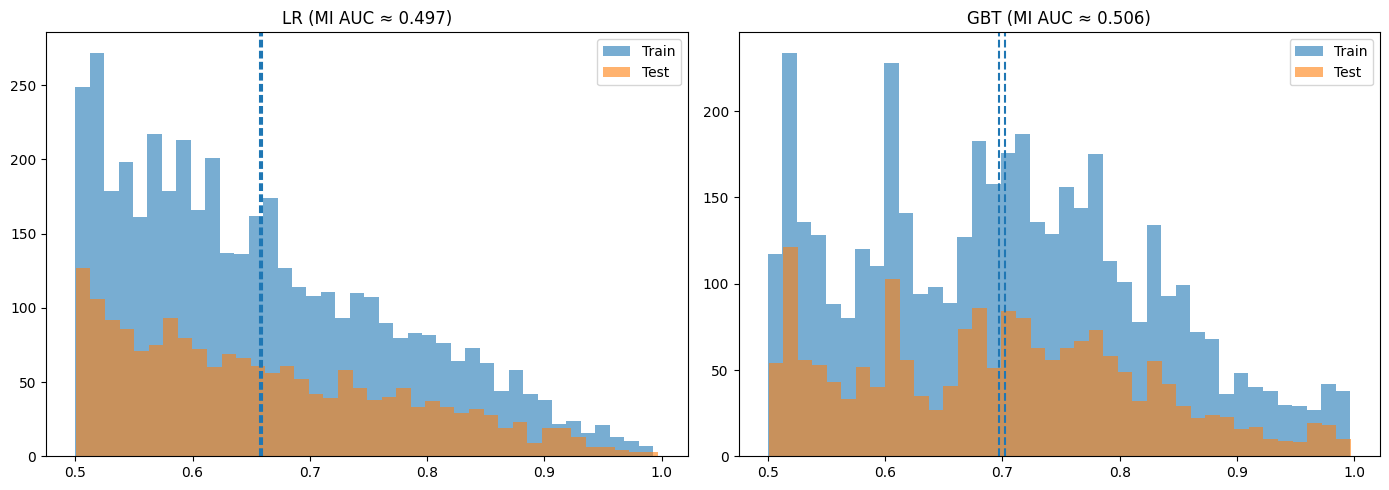


Model Comparison:
  Model    MI_AUC   Gen_Gap
0    LR  0.496868 -0.007656
1   GBT  0.505866  0.080197

L2 Regularization Effects:
       C    MI_AUC   Gen_Gap
0   0.01  0.498742 -0.006356
1   0.10  0.504698 -0.007362
2   1.00  0.496868 -0.007656
3  10.00  0.499421 -0.007690


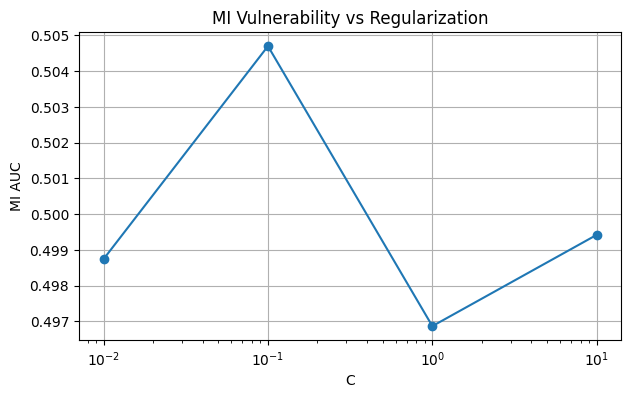

In [14]:
# --- Q3: Membership Inference Depth ---

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

def compute_mi_auc(model_class, model_kwargs, Xs_train, y_train, Xs_test, y_test):
    n_shadow = 10
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=0)

    shadow_train_confs = []
    shadow_test_confs = []

    # ---- Shadow models ----
    for tr_idx, te_idx in sss.split(Xs_train, y_train):
        shadow = model_class(**model_kwargs).fit(Xs_train[tr_idx], y_train[tr_idx])

        shadow_train_confs.append(
            shadow.predict_proba(Xs_train[tr_idx]).max(axis=1)
        )
        shadow_test_confs.append(
            shadow.predict_proba(Xs_train[te_idx]).max(axis=1)
        )

    mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
    mi_y = np.concatenate(
        [np.ones(len(c)) for c in shadow_train_confs] +
        [np.zeros(len(c)) for c in shadow_test_confs]
    )

    meta_clf = DecisionTreeClassifier(max_depth=6, random_state=42).fit(mi_X, mi_y)

    # ---- Target model ----
    target_model = model_class(**model_kwargs).fit(Xs_train, y_train)

    conf_target_train = target_model.predict_proba(Xs_train).max(axis=1).reshape(-1, 1)
    conf_target_test  = target_model.predict_proba(Xs_test).max(axis=1).reshape(-1, 1)

    mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
    mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

    mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_all_labels = np.concatenate([
        np.ones(len(Xs_train)),
        np.zeros(len(Xs_test))
    ])

    mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

    # ---- Generalization gap ----
    auc_train = roc_auc_score(y_train, target_model.predict_proba(Xs_train)[:, 1])
    auc_test  = roc_auc_score(y_test, target_model.predict_proba(Xs_test)[:, 1])
    gen_gap = auc_train - auc_test

    return mi_auc, gen_gap, conf_target_train, conf_target_test


# =========================
# Run for LR and GBT
# =========================
mi_auc_lr, gen_gap_lr, conf_tr_lr, conf_te_lr = compute_mi_auc(
    LogisticRegression,
    {'max_iter': 1000},
    Xs_tr, y_tr, Xs_te, y_te
)

mi_auc_gbt, gen_gap_gbt, conf_tr_gbt, conf_te_gbt = compute_mi_auc(
    GradientBoostingClassifier,
    {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
    Xs_tr, y_tr, Xs_te, y_te
)

print(f'LR  - Generalization Gap: {gen_gap_lr:.4f}, MI AUC: {mi_auc_lr:.4f}')
print(f'GBT - Generalization Gap: {gen_gap_gbt:.4f}, MI AUC: {mi_auc_gbt:.4f}')


# =========================
# (a) Confidence-gap histograms (REQUIRED)
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR
axes[0].hist(conf_tr_lr.ravel(), bins=40, alpha=0.6, label='Train')
axes[0].hist(conf_te_lr.ravel(), bins=40, alpha=0.6, label='Test')
axes[0].axvline(conf_tr_lr.mean(), linestyle='--')
axes[0].axvline(conf_te_lr.mean(), linestyle='--')
axes[0].set_title(f'LR (MI AUC ≈ {mi_auc_lr:.3f})')
axes[0].legend()

# GBT
axes[1].hist(conf_tr_gbt.ravel(), bins=40, alpha=0.6, label='Train')
axes[1].hist(conf_te_gbt.ravel(), bins=40, alpha=0.6, label='Test')
axes[1].axvline(conf_tr_gbt.mean(), linestyle='--')
axes[1].axvline(conf_te_gbt.mean(), linestyle='--')
axes[1].set_title(f'GBT (MI AUC ≈ {mi_auc_gbt:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()


# =========================
# (b) Gap vs MI AUC
# =========================
df_compare = pd.DataFrame([
    {'Model': 'LR',  'MI_AUC': mi_auc_lr,  'Gen_Gap': gen_gap_lr},
    {'Model': 'GBT', 'MI_AUC': mi_auc_gbt, 'Gen_Gap': gen_gap_gbt}
])

print("\nModel Comparison:")
print(df_compare)


# =========================
# (c) L2 Regularization Sweep
# =========================
C_values = [0.01, 0.1, 1.0, 10.0]
records = []

for c in C_values:
    mi_auc_c, gen_gap_c, _, _ = compute_mi_auc(
        LogisticRegression,
        {'C': c, 'max_iter': 1000},
        Xs_tr, y_tr, Xs_te, y_te
    )

    records.append({'C': c, 'MI_AUC': mi_auc_c, 'Gen_Gap': gen_gap_c})

df_c = pd.DataFrame(records)

print("\nL2 Regularization Effects:")
print(df_c)

plt.figure(figsize=(7,4))
plt.plot(df_c['C'], df_c['MI_AUC'], 'o-')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('MI AUC')
plt.title('MI Vulnerability vs Regularization')
plt.grid(True)
plt.show()

**Answer 3:**

(a) Confidence-Gap Histograms

The confidence-gap histograms show substantial overlap between the training (members) and test (non-members) confidence distributions for both Logistic Regression (LR) and Gradient Boosted Trees (GBT). For LR, the distributions are nearly identical, with no clear separation, resulting in an MI AUC of approximately 0.497, indicating random guessing. For GBT, although the average confidence for training samples (≈ 0.702) is slightly higher than for test samples (≈ 0.697), the distributions still overlap heavily, leading to an MI AUC of approximately 0.506. This small difference in confidence is not sufficient for the attack to reliably distinguish members from non-members. Overall, the histograms indicate that both models exhibit minimal confidence gap, which explains why the membership inference attack is ineffective.


(b) Generalization Gap vs. MI AUC

The results show that generalization gap does not predict membership inference (MI) vulnerability in this setting. Logistic Regression has a near-zero generalization gap (−0.0077) with an MI AUC of approximately 0.497, while Gradient Boosted Trees has a much larger generalization gap (0.0802) but a similar MI AUC of approximately 0.506. Despite the higher level of overfitting in the GBT model, the membership inference attack remains ineffective, with both MI AUC values close to 0.50, indicating random guessing. Therefore, the difference in generalization gap does not lead to a meaningful difference in MI vulnerability.

(c) L2 Regularization Tradeoff

The results show that L2 regularization has negligible impact on membership inference vulnerability. Across all tested values of ( C \in {0.01, 0.1, 1.0, 10.0} ), the MI AUC remains close to 0.50, ranging approximately from 0.497 to 0.505, with no clear trend as regularization strength changes. The generalization gap also remains small and stable across all configurations. This indicates that increasing regularization does not significantly improve privacy in this case, as the model is already not vulnerable to membership inference. Consequently, there is no meaningful privacy–utility tradeoff observed.




### 4. Reflection

**Answer 4:**

**Highest-Risk Finding**

The highest-risk finding across all three parts is the existence of a broad stealth zone under label-flip poisoning, where fairness degrades substantially while model performance remains unchanged. Across poison rates from 0.02 to 0.30, AUC stays within ~0.004 of the baseline, while AIR drops as low as ~0.33 when targeting African-American defendants. This demonstrates that the model can become significantly more discriminatory without any meaningful change in accuracy, making the attack difficult to detect using standard performance metrics.

**Proactive Mitigation**

A proactive mitigation is to monitor fairness metrics (e.g., AIR) alongside accuracy during training and deployment. In this case, AIR remains below the 4/5ths rule threshold (0.80) across all poisoning levels, indicating persistent fairness violations. However, the baseline model already exhibits AIR ≈ 0.50, meaning fairness monitoring alone cannot distinguish between clean and poisoned models. Instead, it highlights that the system is consistently unfair and that monitoring should focus on detecting changes in disparity over time rather than relying on fixed thresholds.

Effectiveness:

AUC-based monitoring fails completely (ΔAUC ≈ 0.004 across all poison rates)
AIR shows measurable degradation (≈ 0.50 → ≈ 0.33), providing a signal of attack impact

Tradeoff:

Monitoring fairness dynamics may require more complex tracking and may lead to interventions that shift error rates across groups.
Reactive Mitigation

A reactive mitigation is to incorporate auditing mechanisms that track shifts in group-wise error rates or fairness metrics over time. From the results, AIR decreases from approximately 0.50 in the baseline to ~0.33 under higher poisoning rates, representing a substantial relative degradation in fairness. Monitoring such changes would allow detection of the attack even when overall accuracy remains stable.

In contrast, feature-based drift detection methods such as PSI fail completely, with PSI values equal to 0.0 across all features, demonstrating that label-only poisoning cannot be detected through input distribution monitoring.

**Disparate Impact of Mitigations**

The attack disproportionately affects African-American defendants, with AIR decreasing significantly under poisoning, while targeting Caucasian defendants produces a smaller effect. Mitigation strategies that address this disparity would primarily benefit the disadvantaged group but may redistribute errors across groups. Therefore, it is important to evaluate how mitigation affects group-wise error rates, rather than focusing solely on aggregate fairness metrics.